In [471]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [472]:
df = pd.read_csv('train.csv')
df
df['Rented_Bike_Count'] = np.expm1(df['Rented_Bike_Count'])
(df['Rented_Bike_Count'].unique())
df['Rented_Bike_Count'].describe()
df['Demand'] = df['Rented_Bike_Count'] >= 500
df['Demand'] = df['Demand'].astype('int')
df.drop(columns=['Seasons'], inplace = True)

# for i in df.columns:
#     if(i != 'Demand'):
#         plt.figure(figsize= (8,8))
#         sns.boxplot(data = df, x = 'Demand', y = i)
#         plt.tight_layout()
#         plt.show()
#         plt.close()
#         plt.figure(figsize = (8,8))
#         sns.histplot(data = df, x = i, kde= True, hue = 'Demand')
#         plt.tight_layout()
#         plt.show()
#         plt.close()
df

,Id,Date,Rented_Bike_Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Demand
0,0,01/12/2017,254.0,0,-5.2,37,2.2,2000,-17.6,0.00,0.0,0.0,No Holiday,Yes,0
1,1,01/12/2017,204.0,1,-5.5,38,0.8,2000,-17.6,0.00,0.0,0.0,No Holiday,Yes,0
2,2,01/12/2017,173.0,2,-6.0,39,1.0,2000,-17.7,0.00,0.0,0.0,No Holiday,Yes,0
3,3,01/12/2017,107.0,3,-6.2,40,0.9,2000,-17.6,0.00,0.0,0.0,No Holiday,Yes,0
4,4,01/12/2017,78.0,4,-6.0,36,2.3,2000,-18.6,0.00,0.0,0.0,No Holiday,Yes,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6571,6571,31/08/2018,2372.0,19,26.5,69,2.3,2000,20.3,0.18,0.0,0.0,No Holiday,Yes,1
6572,6572,31/08/2018,1995.0,20,25.4,74,1.6,2000,20.4,0.00,0.0,0.0,No Holiday,Yes,1
6573,6573,31/08/2018,1931.0,21,24.5,78,1.2,2000,20.4,0.00,0.0,0.0,No Holiday,Yes,1
6574,6574,31/08/2018,1789.0,22,24.1,80,0.9,1852,20.4,0.00,0.0,0.0,No Holiday,Yes,1


In [473]:
# df['Humidity'] = df['Humidity(%)'] >= 60
# sns.kdeplot(data = df, x = 'Rented_Bike_Count', hue = 'Humidity')

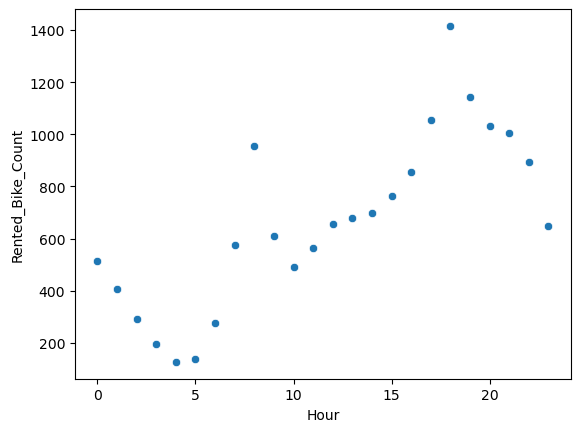

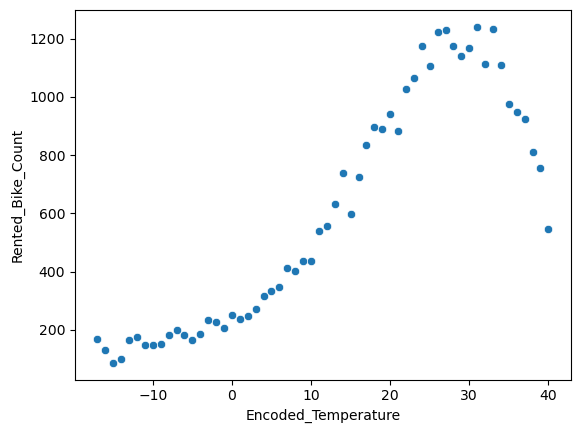

,Id,Date,Rented_Bike_Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Demand,Encoded_Hour,Encoded_Temperature
0,0,01/12/2017,254.0,0,-5.2,37,2.2,4,-17.6,0.00,0.0,0.0,No Holiday,Yes,0,514.153285,165.202899
1,1,01/12/2017,204.0,1,-5.5,38,0.8,4,-17.6,0.00,0.0,0.0,No Holiday,Yes,0,406.412409,165.202899
2,2,01/12/2017,173.0,2,-6.0,39,1.0,4,-17.7,0.00,0.0,0.0,No Holiday,Yes,0,291.594891,182.725000
3,3,01/12/2017,107.0,3,-6.2,40,0.9,4,-17.6,0.00,0.0,0.0,No Holiday,Yes,0,195.956204,182.725000
4,4,01/12/2017,78.0,4,-6.0,36,2.3,4,-18.6,0.00,0.0,0.0,No Holiday,Yes,0,127.277372,182.725000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6571,6571,31/08/2018,2372.0,19,26.5,69,2.3,4,20.3,0.18,0.0,0.0,No Holiday,Yes,1,1144.043796,1228.646707
6572,6572,31/08/2018,1995.0,20,25.4,74,1.6,4,20.4,0.00,0.0,0.0,No Holiday,Yes,1,1033.262774,1223.677632
6573,6573,31/08/2018,1931.0,21,24.5,78,1.2,4,20.4,0.00,0.0,0.0,No Holiday,Yes,1,1003.357664,1107.287037
6574,6574,31/08/2018,1789.0,22,24.1,80,0.9,4,20.4,0.00,0.0,0.0,No Holiday,Yes,1,895.160584,1107.287037


In [474]:
df
mean = df.groupby('Hour')['Rented_Bike_Count'].mean()
#count = df.groupby('Hour')['Rented_Bike_Count'].count()
a0 = df.groupby('Hour')['Rented_Bike_Count'].mean()
df['Encoded_Hour'] = df['Hour'].map(mean)
#df['Hour'].unique()
sns.scatterplot(data = mean)
plt.show()
plt.close()
def ceil(a):
    if(a > (a//1)):
        return (a//1) + 1
    else:
        return (a)

df['Temperature(°C)'].describe()
df['Encoded_Temperature'] = df['Temperature(°C)'].apply(ceil)

mean = df.groupby('Encoded_Temperature')['Rented_Bike_Count'].mean()
a1 = mean
df['Encoded_Temperature'] = df['Encoded_Temperature'].map(mean)
#count = df.groupby('Encoded_Temperature')['Rented_Bike_Count'].count() < 50
#count.value_counts()
def vis(a):
    if(a > 1500):
        return 4
    elif(a > 1000):
        return 3
    elif(a > 500):
        return 2
    else:
        return 1


df['Visibility (10m)'] = df['Visibility (10m)'].apply(vis)
a2 = df['Visibility (10m)']

sns.scatterplot(data = mean)

plt.show()
plt.close()# df['Humidity(%)'] = (df['Humidity(%)']) / 100    ####CHECK THIS OUT
# df['Humidity(%)']

df.describe()
df


In [475]:
df.dtypes

Id                             int64
Date                          object
Rented_Bike_Count            float64
Hour                           int64
Temperature(°C)              float64
Humidity(%)                    int64
Wind speed (m/s)             float64
Visibility (10m)               int64
Dew point temperature(°C)    float64
Solar Radiation (MJ/m2)      float64
Rainfall(mm)                 float64
Snowfall (cm)                float64
Holiday                       object
Functioning Day               object
Demand                         int64
Encoded_Hour                 float64
Encoded_Temperature          float64
dtype: object

<Axes: xlabel='Dew_Temperature_Encoded', ylabel='Rented_Bike_Count'>

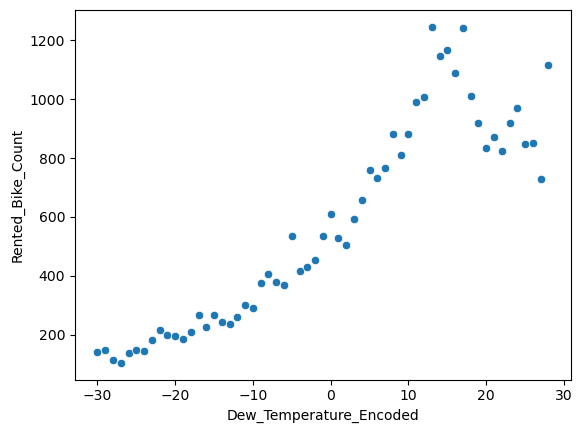

In [476]:
df['Dew_Temperature_Encoded'] = df['Dew point temperature(°C)'].apply(ceil)

mean = df.groupby('Dew_Temperature_Encoded')['Rented_Bike_Count'].mean()
a3 = mean
df['Dew_Temperature_Encoded'] = df['Dew_Temperature_Encoded'].map(mean)
mean
sns.scatterplot(data = mean)

In [477]:
# d = {
#     'Summer' : 3,
#     'Winter' : 1,
#     'Spring' : 2
# }
# df['Seasons'] = df['Seasons'].map(d)
# mean = df.groupby('Seasons')['Rented_Bike_Count'].mean()
# a4 = mean
# df['Seasons'] = df['Seasons'].map(mean)
# mean
# df
# sns.scatterplot(data = mean,linestyle = '-', markers='o')
# plt.tight_layout()
# plt.show()
# plt.close()


In [478]:
d = {
    'No Holiday' : 0,
    'Yes' : 1,
    'No' : 0,
    'Holiday':1   
}

df['Holiday'] = df['Holiday'].map(d)
df['Functioning Day'] = df['Functioning Day'].map(d)
df = df.drop(columns=['Demand'])
df

,Id,Date,Rented_Bike_Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Encoded_Hour,Encoded_Temperature,Dew_Temperature_Encoded
0,0,01/12/2017,254.0,0,-5.2,37,2.2,4,-17.6,0.00,0.0,0.0,0,1,514.153285,165.202899,266.577320
1,1,01/12/2017,204.0,1,-5.5,38,0.8,4,-17.6,0.00,0.0,0.0,0,1,406.412409,165.202899,266.577320
2,2,01/12/2017,173.0,2,-6.0,39,1.0,4,-17.7,0.00,0.0,0.0,0,1,291.594891,182.725000,266.577320
3,3,01/12/2017,107.0,3,-6.2,40,0.9,4,-17.6,0.00,0.0,0.0,0,1,195.956204,182.725000,266.577320
4,4,01/12/2017,78.0,4,-6.0,36,2.3,4,-18.6,0.00,0.0,0.0,0,1,127.277372,182.725000,210.203704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6571,6571,31/08/2018,2372.0,19,26.5,69,2.3,4,20.3,0.18,0.0,0.0,0,1,1144.043796,1228.646707,870.811321
6572,6572,31/08/2018,1995.0,20,25.4,74,1.6,4,20.4,0.00,0.0,0.0,0,1,1033.262774,1223.677632,870.811321
6573,6573,31/08/2018,1931.0,21,24.5,78,1.2,4,20.4,0.00,0.0,0.0,0,1,1003.357664,1107.287037,870.811321
6574,6574,31/08/2018,1789.0,22,24.1,80,0.9,4,20.4,0.00,0.0,0.0,0,1,895.160584,1107.287037,870.811321


In [479]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer

X_train = df
scaler = PowerTransformer(method='yeo-johnson')
X_train['Humidity(%)'] = scaler.fit_transform(X_train[['Humidity(%)']])
scaler2 = MinMaxScaler(feature_range=(0,1))
scaler3 = RobustScaler()
scaler4 = PowerTransformer(method='yeo-johnson')
scaler5 = PowerTransformer(method='yeo-johnson')
scaler6 = PowerTransformer(method='yeo-johnson')
scaler9 = PowerTransformer(method='yeo-johnson')
scaler10 = PowerTransformer(method='yeo-johnson')
scaler7 = MinMaxScaler(feature_range=(0,1))
scaler8 = MinMaxScaler(feature_range=(0,1))
X_train['Encoded_Temperature'] = scaler4.fit_transform(X_train[['Encoded_Temperature']])
X_train['Dew_Temperature_Encoded'] = scaler5.fit_transform(X_train[['Dew_Temperature_Encoded']])
X_train['Encoded_Hour'] = scaler6.fit_transform(X_train[['Encoded_Hour']])
#X_train['Seasons'] = scaler2.fit_transform(X_train[['Seasons']])
X_train['Visibility (10m)'] = scaler7.fit_transform(X_train[['Visibility (10m)']])
X_train['Wind speed (m/s)'] = scaler9.fit_transform(X_train[['Wind speed (m/s)']])
X_train['Solar Radiation (MJ/m2)'] = scaler10.fit_transform(X_train[['Solar Radiation (MJ/m2)']])
df['Temperature(°C)'] = df['Temperature(°C)'].apply(ceil)
df['Dew point temperature(°C)'] = df['Dew point temperature(°C)'].apply(ceil)
# sns.scatterplot(data = X_train, x='Temperature(°C)', y= 'Encoded_Temperature')
# plt.tight_layout()
# plt.show()
# plt.close()
# sns.scatterplot(data = X_train, x='Dew point temperature(°C)', y= 'Dew_Temperature_Encoded')
# plt.tight_layout()
# plt.show()
# plt.close()
# sns.scatterplot(data = X_train, y='Encoded_Hour', x= 'Hour')
# plt.tight_layout()
# plt.show()
# plt.close()
# sns.kdeplot(data=X_train, x = 'Humidity(%)')




In [480]:
#sns.kdeplot(data=X_train, x = 'Dew_Temperature_Encoded')

df

,Id,Date,Rented_Bike_Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Encoded_Hour,Encoded_Temperature,Dew_Temperature_Encoded
0,0,01/12/2017,254.0,0,-5.0,-0.993522,0.540744,1.0,-17.0,-0.857199,0.0,0.0,0,1,-0.386083,-1.447458,-1.271553
1,1,01/12/2017,204.0,1,-5.0,-0.942235,-0.996921,1.0,-17.0,-0.857199,0.0,0.0,0,1,-0.739420,-1.447458,-1.271553
2,2,01/12/2017,173.0,2,-6.0,-0.891193,-0.715700,1.0,-17.0,-0.857199,0.0,0.0,0,1,-1.147735,-1.357363,-1.271553
3,3,01/12/2017,107.0,3,-6.0,-0.840388,-0.852629,1.0,-17.0,-0.857199,0.0,0.0,0,1,-1.525330,-1.357363,-1.271553
4,4,01/12/2017,78.0,4,-6.0,-1.045061,0.623116,1.0,-18.0,-0.857199,0.0,0.0,0,1,-1.830798,-1.357363,-1.503052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6571,6571,31/08/2018,2372.0,19,27.0,0.552502,0.623116,1.0,21.0,-0.111374,0.0,0.0,0,1,1.370738,1.262956,0.667359
6572,6572,31/08/2018,1995.0,20,26.0,0.780411,-0.014723,1.0,21.0,-0.857199,0.0,0.0,0,1,1.087876,1.254973,0.667359
6573,6573,31/08/2018,1931.0,21,25.0,0.960700,-0.461168,1.0,21.0,-0.857199,0.0,0.0,0,1,1.010035,1.062163,0.667359
6574,6574,31/08/2018,1789.0,22,25.0,1.050203,-0.852629,1.0,21.0,-0.857199,0.0,0.0,0,1,0.722558,1.062163,0.667359


In [481]:
X_train.drop(columns=['Temperature(°C)', 'Dew point temperature(°C)'], inplace= True)
X_train

,Id,Date,Rented_Bike_Count,Hour,Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Encoded_Hour,Encoded_Temperature,Dew_Temperature_Encoded
0,0,01/12/2017,254.0,0,-0.993522,0.540744,1.0,-0.857199,0.0,0.0,0,1,-0.386083,-1.447458,-1.271553
1,1,01/12/2017,204.0,1,-0.942235,-0.996921,1.0,-0.857199,0.0,0.0,0,1,-0.739420,-1.447458,-1.271553
2,2,01/12/2017,173.0,2,-0.891193,-0.715700,1.0,-0.857199,0.0,0.0,0,1,-1.147735,-1.357363,-1.271553
3,3,01/12/2017,107.0,3,-0.840388,-0.852629,1.0,-0.857199,0.0,0.0,0,1,-1.525330,-1.357363,-1.271553
4,4,01/12/2017,78.0,4,-1.045061,0.623116,1.0,-0.857199,0.0,0.0,0,1,-1.830798,-1.357363,-1.503052
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6571,6571,31/08/2018,2372.0,19,0.552502,0.623116,1.0,-0.111374,0.0,0.0,0,1,1.370738,1.262956,0.667359
6572,6572,31/08/2018,1995.0,20,0.780411,-0.014723,1.0,-0.857199,0.0,0.0,0,1,1.087876,1.254973,0.667359
6573,6573,31/08/2018,1931.0,21,0.960700,-0.461168,1.0,-0.857199,0.0,0.0,0,1,1.010035,1.062163,0.667359
6574,6574,31/08/2018,1789.0,22,1.050203,-0.852629,1.0,-0.857199,0.0,0.0,0,1,0.722558,1.062163,0.667359


In [482]:
X_train['Date'] = pd.to_datetime(X_train['Date'], format="%d/%m/%Y")

# X_train['Day'] = X_train['Date'].dt.day
# X_train['Month'] = X_train['Date'].dt.month
# X_train['Year'] = X_train['Date'].dt.year
X_train['DOW'] = X_train['Date'].dt.day_of_week

# mean1 = df.groupby('Day')['Rented_Bike_Count'].mean()
# mean2 = df.groupby('Month')['Rented_Bike_Count'].mean()
# mean3 = df.groupby('Year')['Rented_Bike_Count'].mean()
mean4 = df.groupby('DOW')['Rented_Bike_Count'].mean()

X_train['DOW'] = X_train['DOW'].map(mean4)
X_train['DOW'] = scaler8.fit_transform(X_train[['DOW']])

# sns.scatterplot(data = X_train, y='Rented_Bike_Count', x= 'Day')
# plt.tight_layout()
# plt.show()
# plt.close()
# sns.scatterplot(data = X_train, y='Rented_Bike_Count', x= 'Month')
# plt.tight_layout()
# plt.show()
# plt.close()
# sns.scatterplot(data = X_train, y='Rented_Bike_Count', x= 'Year')
# plt.tight_layout()
# plt.show()
# plt.close()
# sns.scatterplot(data = X_train, y='Rented_Bike_Count', x= 'DOW', alpha= 0.05)
# plt.tight_layout()
# plt.show()
# plt.close()


In [483]:
X_train.drop(columns=['Date', 'Id', 'Hour', 'Rainfall(mm)', 'Snowfall (cm)',
       'Holiday', 'Functioning Day', 'Humidity(%)'], inplace= True)

In [484]:
#########################################################################################################

In [485]:
df2 = pd.read_csv('test.csv')





df2.drop(columns=['Seasons'], inplace = True)

mean = a0

df2['Encoded_Hour'] = df2['Hour'].map(mean)

df2['Encoded_Temperature'] = df2['Temperature(°C)'].apply(ceil)
mean = a1
df2['Encoded_Temperature'] = df2['Encoded_Temperature'].map(a1)




df2['Visibility (10m)'] = df2['Visibility (10m)'].apply(vis)





df2['Dew_Temperature_Encoded'] = df2['Dew point temperature(°C)'].apply(ceil)

mean = a3
df2['Dew_Temperature_Encoded'] = df2['Dew_Temperature_Encoded'].map(mean)







# df2['Seasons'] = df2['Seasons'].map(d)
# mean = a4
# df2['Seasons'] = df2['Seasons'].map(mean)








df2['Holiday'] = df2['Holiday'].map(d)
df2['Functioning Day'] = df2['Functioning Day'].map(d)






In [486]:
X_test = df2

X_test['Humidity(%)'] = scaler.transform(X_test[['Humidity(%)']])

X_test['Encoded_Temperature'] = scaler4.transform(X_test[['Encoded_Temperature']])
X_test['Dew_Temperature_Encoded'] = scaler5.transform(X_test[['Dew_Temperature_Encoded']])
X_test['Encoded_Hour'] = scaler6.transform(X_test[['Encoded_Hour']])
#X_test['Seasons'] = scaler2.transform(X_test[['Seasons']])
X_test['Visibility (10m)'] = scaler7.transform(X_test[['Visibility (10m)']])
X_test['Wind speed (m/s)'] = scaler9.transform(X_test[['Wind speed (m/s)']])
X_test['Solar Radiation (MJ/m2)'] = scaler10.transform(X_test[['Solar Radiation (MJ/m2)']])



X_test.drop(columns=['Temperature(°C)', 'Dew point temperature(°C)'], inplace= True)








X_test['Date'] = pd.to_datetime(X_test['Date'], format="%d/%m/%Y")

X_test['DOW'] = X_test['Date'].dt.day_of_week

X_test['DOW'] = X_test['DOW'].map(mean4)
X_test['DOW'] = scaler8.transform(X_test[['DOW']])




test_data_id = X_test['Id']

X_test.drop(columns=['Date', 'Id', 'Hour', 'Rainfall(mm)', 'Snowfall (cm)',
       'Holiday', 'Functioning Day', 'Humidity(%)'], inplace= True)



In [487]:
#X_test['Seasons'].isna().value_counts()
#test_data_id


In [488]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
y_train = np.log1p(X_train['Rented_Bike_Count'])
X_train = (X_train.drop(columns=['Rented_Bike_Count']))
lr = LinearRegression().fit(X_train, y_train)

print(lr.score(X_train, y_train))


from sklearn.metrics import root_mean_squared_error

val_predictions = lr.predict(X_train)

# Calculate and print the Root Mean Squared Error (RMSE)
val_rmse = root_mean_squared_error((y_train), (val_predictions))
print(f"Local Validation RMSE: {val_rmse:.4f}")

0.5127451808319051
Local Validation RMSE: 0.8905


In [489]:
display(X_train)
display(X_test)

,Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Encoded_Hour,Encoded_Temperature,Dew_Temperature_Encoded,DOW
0,0.540744,1.0,-0.857199,-0.386083,-1.447458,-1.271553,1.0
1,-0.996921,1.0,-0.857199,-0.739420,-1.447458,-1.271553,1.0
2,-0.715700,1.0,-0.857199,-1.147735,-1.357363,-1.271553,1.0
3,-0.852629,1.0,-0.857199,-1.525330,-1.357363,-1.271553,1.0
4,0.623116,1.0,-0.857199,-1.830798,-1.357363,-1.503052,1.0
...,...,...,...,...,...,...,...
6571,0.623116,1.0,-0.111374,1.370738,1.262956,0.667359,1.0
6572,-0.014723,1.0,-0.857199,1.087876,1.254973,0.667359,1.0
6573,-0.461168,1.0,-0.857199,1.010035,1.062163,0.667359,1.0
6574,-0.852629,1.0,-0.857199,0.722558,1.062163,0.667359,1.0


,Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Encoded_Hour,Encoded_Temperature,Dew_Temperature_Encoded,DOW
0,-1.483185,1.000000,-0.857199,-0.386083,1.174168,0.667359,0.472193
1,-2.309293,1.000000,-0.857199,-0.739420,0.986614,0.569222,0.472193
2,-1.667069,1.000000,-0.857199,-1.147735,0.923068,0.569222,0.472193
3,-1.864510,1.000000,-0.857199,-1.525330,0.923068,0.569222,0.472193
4,-0.852629,0.666667,-0.857199,-1.830798,0.923068,0.569222,0.472193
...,...,...,...,...,...,...,...
2179,0.856108,1.000000,-0.857199,1.370738,-0.734561,-1.176287,1.000000
2180,0.623116,1.000000,-0.857199,1.087876,-0.801890,-0.864604,1.000000
2181,-1.864510,1.000000,-0.857199,1.010035,-0.961571,-0.864604,1.000000
2182,-0.715700,1.000000,-0.857199,0.722558,-0.961571,-0.864604,1.000000


In [490]:
lasso = Lasso(alpha= 1)
lasso.fit(X_train, y_train)

print(lasso.score(X_train, y_train))



val_predictions = lasso.predict(X_train)

# Calculate and print the Root Mean Squared Error (RMSE)
val_rmse = root_mean_squared_error(y_train, val_predictions)
print(f"Local Validation RMSE: {val_rmse:.4f}")
print(lasso.coef_)
print(lasso.intercept_)
lasso.feature_names_in_


0.0
Local Validation RMSE: 1.2757
[0. 0. 0. 0. 0. 0. 0.]
5.927950162213541


array(['Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)',
       'Encoded_Hour', 'Encoded_Temperature', 'Dew_Temperature_Encoded',
       'DOW'], dtype=object)

In [491]:
ridge = Ridge(alpha= 0.001)
ridge.fit(X_train, y_train)

print(ridge.score(X_train, y_train))



val_predictions = ridge.predict(X_train)

# Calculate and print the Root Mean Squared Error (RMSE)
val_rmse = root_mean_squared_error(y_train, val_predictions)
print(f"Local Validation RMSE: {val_rmse:.4f}")
ridge.coef_


0.5127451808318225
Local Validation RMSE: 0.8905


array([-0.08538719,  0.55701048,  0.16204455,  0.47306336,  0.60482343,
        0.002003  ,  0.46530482])

In [492]:
test_predictions = ridge.predict(X_test)

# Create the submission dataframe
submission = pd.DataFrame({
    'Id': test_data_id,
    'Rented_Bike_Count': (test_predictions)
})

# Display the first few rows of the submission
display(submission.head())

# Export to CSV (without the pandas index)
submission.to_csv('submission6.csv', index=False)

,Id,Rented_Bike_Count
0,6576,6.600542
1,6577,6.390297
2,6578,6.103866
3,6579,5.942099
4,6580,5.525521


In [493]:
display(submission.describe())
(submission['Rented_Bike_Count'] >= 0).value_counts()

,Id,Rented_Bike_Count
count,2184.000000,2184.000000
mean,7667.500000,6.101740
std,630.610815,0.795710
min,6576.000000,3.818101
25%,7121.750000,5.542131
50%,7667.500000,6.149377
75%,8213.250000,6.720252
max,8759.000000,8.074988


Rented_Bike_Count
True    2184
Name: count, dtype: int64

In [494]:
submission[submission['Rented_Bike_Count'] < 0].sort_values(by='Rented_Bike_Count')

,Id,Rented_Bike_Count


In [495]:
np.log1p(submission.iloc[[411,  412,  413,  414,  435,  436,  437,  438,  509,  650, 1656], :]['Rented_Bike_Count'])

411     1.921606
412     1.902573
413     1.904648
414     1.952184
435     1.924232
436     1.902911
437     1.898297
438     1.915539
509     1.842536
650     1.925163
1656    1.898337
Name: Rented_Bike_Count, dtype: float64

<Axes: xlabel='Id', ylabel='Rented_Bike_Count'>

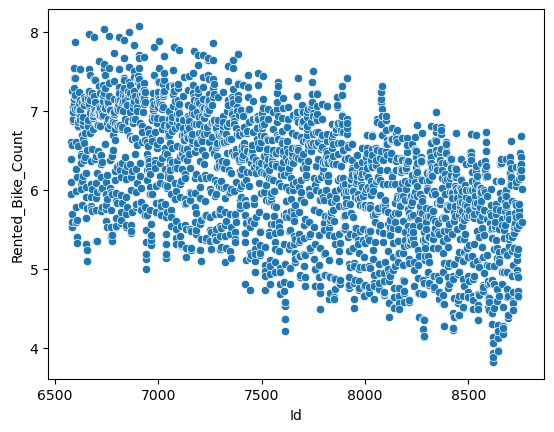

In [496]:
sns.scatterplot(data = submission, x = 'Id', y = 'Rented_Bike_Count')